Damped Harmonic Oscillator Simulation  
Author: Zachary Lee
<hr>

A harmonic oscillator is a system that experiences oscillations due to a restoring force proportional to its displacement from equilibrium. Real systems lose energy over time due to friction or drag, which is captured by a damping term. Combining Newton's Second Law with Hooke's Law and a velocity-dependent damping force gives the equation of motion:
$$\boxed{\ddot{x} + 2\gamma\dot{x} + \omega^2x = 0}$$
where $\gamma = \frac{b}{2m}$ is the damping constant and $\omega = \sqrt{\frac{k}{m}}$ is the natural frequency. The behavior of the system depends on the relationship between $\gamma$ and $\omega$.

1) Underdamped ($\gamma < \omega$):  
    * The system oscillates with decreasing amplitude.  
2) Overdamped ($\gamma > \omega$):  
    * The system returns to equilibrium slowly without oscillating.  
3) Critically Damped ($\gamma = \omega$):  
    * The system returns to equilibrium as quickly as possible without oscillating.  

For the full derivation, see [theory.md](../docs/theory.md).

This simulation with will Euler's method and compare it to the analytical method.
<hr>

In [122]:
# Import Cell
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
# Class Definition Cell
class DampedOscillator:
    def __init__(self, m=1.0, k=10.0, b=1.0): # m is the mass, k is the spring constant, and b is the damping coefficient.
        self.m = m
        self.k = k
        self.b = b
        self.gamma = b / (2 * m)
        self.omega = np.sqrt(k / m)
    
    # ----------------------------------------------------------
    # Derivative Method
    # This method calculates the derivatives of position and velocity based on the current state.
    # ----------------------------------------------------------

    def _derivative(self, state):
            x = state[0] # position.
            v = state[1] # velocity.
            dxdt = v
            dvdt = -2 * self.gamma * v - self.omega**2 * x # refer to theory.md to find out how this equation is derived. 
            return np.array([dxdt, dvdt]) # array that contains the derivatives of position and velocity.

    # ----------------------------------------------------------
    # Simulation and Plotting Methods
    # x0 and v0 are the initial conditions for position and velocity.
    # dt is the time step for the simulation, t_max is the maximum simulation time, and threshold is the stopping condition for the simulation.
    # You can choose between the Runge-Kutta 4th order method (rk4) or the Euler method (euler) for the simulation.
    # I've found that both methods, given my parameters, yield similar results, but the rk4 method is more accurate and stable for larger time steps.
    # For example, with dt=0.01, the difference in time to reach equilibrium is 0.005 seconds between the two methods, with rk4 being more accurate.
    # ----------------------------------------------------------       

    def simulate(self, x0=1.0, v0=0.0, dt=0.001, t_max=30.0, threshold=1e-3, method="rk4"):
        state = np.array([x0, v0])

        times = []
        positions = []
        velocities = []
        t = 0.0

        while t < t_max:
            if method == "rk4":
                k1 = self._derivative(state)
                k2 = self._derivative(state + 0.5 * dt * k1)
                k3 = self._derivative(state + 0.5 * dt * k2)
                k4 = self._derivative(state + dt * k3)
                state = state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
            elif method == "euler":
                deriv = self._derivative(state)
                state = state + deriv * dt
            else:
                raise ValueError(f"Unknown method '{method}'. Choose 'euler' or 'rk4'.")

            t += dt
            times.append(t)
            positions.append(state[0])
            velocities.append(state[1])

            if abs(state[0]) < threshold and abs(state[1]) < threshold:
                break

        self.times = np.array(times)
        self.positions = np.array(positions)
        self.velocities = np.array(velocities)
        self.method = method

    # ----------------------------------------------------------
    # Plotting Method
    # This method plots the position of the oscillator over time, with options to show the analytical solution and equilibrium point.
    # ----------------------------------------------------------

    def plot(self, label=None, show_analytical=False, show_equilibrium=False, first=False): # Plots the position of the oscillator over time.
            if label is None:
                if self.gamma < self.omega:
                    label = f"Underdamped (b={self.b:.2f})"
                elif self.gamma > self.omega:
                    label = f"Overdamped (b={self.b:.2f})"
                else:
                    label = f"Critically Damped (b={self.b:.2f})"

            plt.plot(self.times, self.positions, label=label)

            if show_analytical:
                analytical_label = "Analytical" if first else "_nolegend_"
                plt.plot(self.analytical_times, self.analytical_positions, color='red', linestyle=(0, (1, 10)), label=analytical_label)

            if show_equilibrium:
                equilibrium_label = "Equilibrium" if first else "_nolegend_"
                t_eq = self.equilibrium_time()
                plt.plot(t_eq, 0.0, marker="+", color='black', markersize=8, label=equilibrium_label)

    # ----------------------------------------------------------
    # Damping Type Method
    # This method determines the type of damping based on the relationship between the damping coefficient and the natural frequency.
    # ----------------------------------------------------------

    def damping_type(self):
        if self.gamma < self.omega:
            return "Underdamped"
        elif self.gamma > self.omega:
            return "Overdamped"
        else:
            return "Critically Damped"

    # ----------------------------------------------------------
    # Phase Space Plotting Method
    # This method plots the phase space of the oscillator, which is a plot of velocity vs. position.
    # ----------------------------------------------------------

    def plot_phase(self, label=None, first=False):
        if label is None:
            if self.gamma < self.omega:
                label = f"Underdamped (b={self.b:.2f})"
            elif self.gamma > self.omega:
                label = f"Overdamped (b={self.b:.2f})"
            else:
                label = f"Critically Damped (b={self.b:.2f})"

        plt.plot(self.positions, self.velocities, label=label)

        if first:
            plt.plot(self.positions[0], self.velocities[0], 
                    marker="o", color="black", markersize=4, label="Start")
            plt.plot(self.positions[-1], self.velocities[-1], 
                    marker="x", color="black", markersize=4, label="Equilibrium")
        else:
            plt.plot(self.positions[0], self.velocities[0], 
                    marker="o", color="black", markersize=4, label="_nolegend_")
            plt.plot(self.positions[-1], self.velocities[-1], 
                    marker="x", color="black", markersize=4, label="_nolegend_")

    # ----------------------------------------------------------
    # Energy Plotting Method
    # This method plots the kinetic, potential, and total energy of the oscillator over time.
    # ----------------------------------------------------------

    def plot_energy(self, label=None, first=False):
        KE = 0.5 * self.m * self.velocities**2 # Kinetic Energy = 0.5 * mass * velocity^2.
        PE = 0.5 * self.k * self.positions**2 # Potential Energy = 0.5 * spring constant * position^2.
        E = KE + PE #Total Energy = Kinetic Energy + Potential Energy.

        if first:
            plt.plot(self.times, KE, linestyle="--", color="blue", label="Kinetic Energy")
            plt.plot(self.times, PE, linestyle=":", color="red", label="Potential Energy")
            plt.plot(self.times, E, linestyle="-", color="black", label="Total Energy")
        else:
            plt.plot(self.times, KE, linestyle="--", color="blue", label="_nolegend_")
            plt.plot(self.times, PE, linestyle=":", color="red", label="_nolegend_")
            plt.plot(self.times, E, linestyle="-", color="black", label="_nolegend_")
                    
    # ----------------------------------------------------------
    # Analytical Solution Method
    # This method calculates the analytical solution for the damped harmonic oscillator based on the damping type.
    # ----------------------------------------------------------

    def analytical(self, x0=1.0, v0=0.0, t_max=30.0): # Analytical solution for the damped harmonic oscillator based on the damping type.
        t = np.linspace(0, t_max, 10000) # Creates an array of time values from 0 to t_max with 10000 points.

        if self.gamma < self.omega:
            # Underdamped
            omega_d = np.sqrt(self.omega**2 - self.gamma**2)
            A = x0
            B = (v0 + self.gamma * x0) / omega_d
            x = np.exp(-self.gamma * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

        elif self.gamma > self.omega:
            # Overdamped
            r1 = -self.gamma + np.sqrt(self.gamma**2 - self.omega**2)
            r2 = -self.gamma - np.sqrt(self.gamma**2 - self.omega**2)
            C = (v0 - r2 * x0) / (r1 - r2)
            D = x0 - C
            x = C * np.exp(r1 * t) + D * np.exp(r2 * t)

        else:
            # Critically Damped
            A = x0
            B = v0 + self.gamma * x0
            x = (A + B * t) * np.exp(-self.gamma * t)

        self.analytical_times = t # array of time values for the analytical solution.
        self.analytical_positions = x # array of position values for the analytical solution. 

    # ----------------------------------------------------------
    # Equilibrium Time Calculation Method
    # This method calculates the time it takes for the system to reach equilibrium based on a specified threshold (epsilon).
    # Used to ensure that the markers for equilibrium are placed correctly on the plots.
    # ---------------------------------------------------------- 

    def equilibrium_time(self, epsilon=1e-3):
        for i, (x, v) in enumerate(zip(self.positions, self.velocities)):
            if abs(x) < epsilon and abs(v) < epsilon:
                return self.times[i]
        return t_eq            

## Simulation Results
The following simulation compares the three damping cases using numerical integration. 
The analytical solution is plotted alongside the numerical result to validate the simulation.

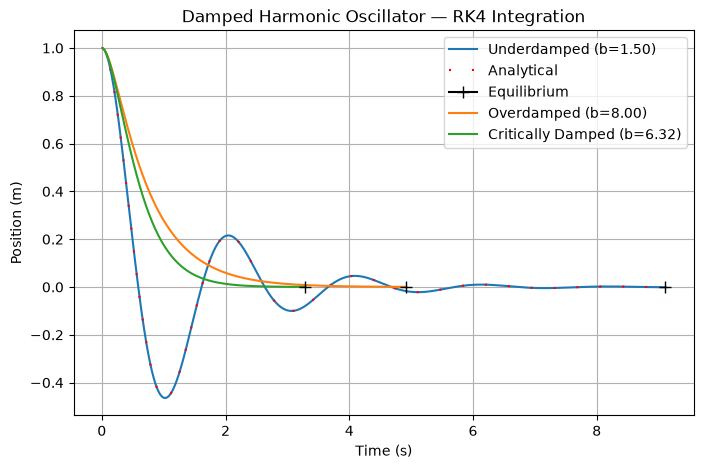

In [124]:
# Main Simulation and Plotting Cell
method = "rk4"  # Change to "euler" to switch methods

plt.figure(figsize=(8, 5))

for i, b in enumerate([1.5, 8, 2 * np.sqrt(10)]):
    first = i == 0
    osc = DampedOscillator(m=1, k=10, b=b)
    osc.simulate(dt=0.01, method=method)
    osc.analytical(t_max=osc.times[-1])
    osc.plot(show_analytical=first, show_equilibrium=True, first=first)

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title(f"Damped Harmonic Oscillator — {method.upper()} Integration")
plt.legend()
plt.grid(True)
plt.show()

## Phase Portrait
A phase portrait plots velocity against position rather than against time. 
Each trajectory spirals or curves into the origin, showing how the system loses energy over time.

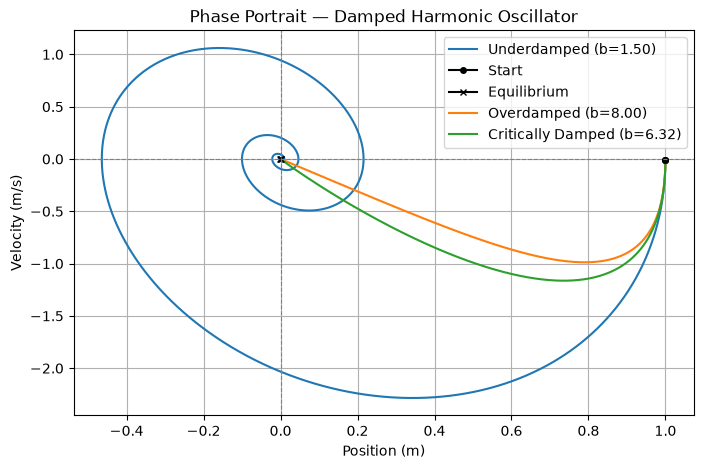

In [125]:
# Cell to Plot Phase Space
plt.figure(figsize=(8, 5))

# ----------------------------------------------------------------
# Simulate and Plot Phase Portraits of Damped Harmonic Oscillators.
# ----------------------------------------------------------------

for i, b in enumerate([1.5, 8, 2 * np.sqrt(10)]):
    first = i == 0
    osc = DampedOscillator(m=1, k=10, b=b)
    osc.simulate()
    osc.plot_phase(first=first)

plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Portrait — Damped Harmonic Oscillator")
plt.axhline(y=0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(x=0, color="gray", linewidth=0.8, linestyle="--")
plt.legend()
plt.grid(True)
plt.show()


## Energy Analysis
The following plots show how kinetic, potential, and total energy evolve over time for each damping case.
In the underdamped case, kinetic and potential energy oscillate back and forth while the total energy decays smoothly.

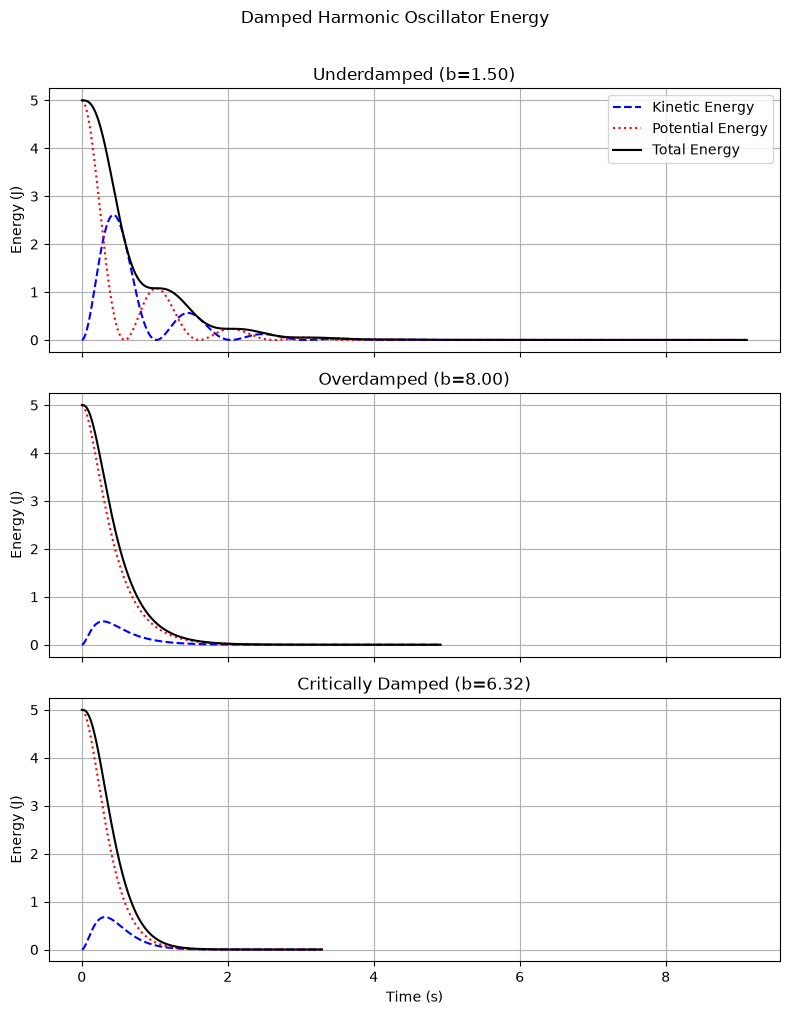

In [126]:
# Cell to Plot Energy
plt.close('all')
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# ----------------------------------------------------------------
# Simulate and Plot Energy of Damped Harmonic Oscillators.
# ----------------------------------------------------------------

for i, b in enumerate([1.5, 8, 2 * np.sqrt(10)]):
    plt.sca(axes[i])
    osc = DampedOscillator(m=1, k=10, b=b)
    osc.simulate()
    osc.plot_energy(first=(i == 0))
    
    plt.title(f"{osc.damping_type()} (b={osc.b:.2f})")
    plt.ylabel("Energy (J)")
    plt.grid(True)

    if i == 0:
        plt.legend()

plt.xlabel("Time (s)")
plt.suptitle("Damped Harmonic Oscillator Energy", y=1.01)
plt.tight_layout()
plt.show()

## Interactive Simulation
Use the sliders below to explore how changing the mass, spring constant, and damping coefficient affects the system.
The "Snap to Critical Damping" button automatically sets the damping coefficient to the critical value for the current mass and spring constant.

In [ ]:
# Widgets Cell for Interactive Exploration
%matplotlib inline

# --------------------------------------------------------------------------
# Sliders for Mass (m), Spring Constant (k), and Damping Coefficient (b)
# Added a button to snap the damping coefficient to the critical damping value based on the current mass and spring constant.
# --------------------------------------------------------------------------

m_slider = widgets.FloatSlider(min=0.5, max=5.0, step=0.5, value=1.0, description="Mass (m)", style={"description_width": "initial"})
k_slider = widgets.FloatSlider(min=1.0, max=20.0, step=0.5, value=10.0, description="Spring (k)", style={"description_width": "initial"})
b_slider = widgets.FloatSlider(min=0.1, max=15.0, step=0.1, value=1.5, description="Damping (b)", style={"description_width": "initial"})
method_dropdown = widgets.Dropdown(options=["rk4", "euler"], value="rk4", description="Method", style={"description_width": "initial"})

# I found it hard to manually adjust the damping coefficient to the critical damping value using the slider,
# so I added a button that automatically sets it based on the current mass and spring constant.
critical_button = widgets.Button( 
    description="Snap to Critical Damping",
    icon="check",
    style=widgets.ButtonStyle(button_color="green", text_color="white"),
    layout=widgets.Layout(width="200px", height="35px")
)

def snap_to_critical(button):
    b_slider.value = 2 * np.sqrt(k_slider.value * m_slider.value)

critical_button.on_click(snap_to_critical)

ui = widgets.VBox([
    m_slider,
    k_slider,
    b_slider,
    method_dropdown,
    critical_button
])

def interactive_plot(m, k, b, method):
    plt.figure(figsize=(8, 5))
    
    osc = DampedOscillator(m=m, k=k, b=b)
    osc.simulate(method=method)
    osc.analytical(t_max=osc.times[-1])
    osc.plot(show_analytical=True, show_equilibrium=True, first=True)
    
    t_eq = osc.equilibrium_time()
    critical_b = 2 * np.sqrt(k * m)
    print(f"Damping Type:      {osc.damping_type()}")
    print(f"Gamma:             {osc.gamma:.3f}  |  Omega: {osc.omega:.3f}")
    print(f"Critical b:        {critical_b:.3f}")
    print(f"Equilibrium at t = {t_eq:.3f}s")
    
    plt.xlabel("Time (s)")
    plt.ylabel("Position (m)")
    plt.title(f"Damped Harmonic Oscillator — {method.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

out = widgets.interactive_output(
    interactive_plot,
    {"m": m_slider, "k": k_slider, "b": b_slider, "method": method_dropdown}
)

display(ui, out)

Output()